# Лабораторная работа №4 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б

#### Цель работы. Изучение линейных моделей, SVM и деревьев решений.

## 1. Импорт библиотек и загрузка датасета

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

#загрузка датасета
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')
feature_names = iris.feature_names

## 2. Проверка наличия пропусков и необходимости предобработки

In [10]:
print(f"Количество образцов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Признаки: {feature_names}")
print(f"Диапазон целевой переменной: [{y.min():.1f}, {y.max():.1f}]")

print(f"Пропуски в признаках: {np.isnan(X).sum()}")
print(f"Пропуски в целевой переменной: {np.isnan(y).sum()}")

Количество образцов: 150
Количество признаков: 4
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Диапазон целевой переменной: [0.0, 2.0]
Пропуски в признаках: sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64
Пропуски в целевой переменной: 0


#### В наборе находятся только числовые признаки, выявлено также отсутствие пропусков, так что дальнейшая обработка не требуется.

## 3. Разделение выборки на обучающую и тестовую

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.0f}%)")

Обучающая выборка: 105 образцов (70%)
Тестовая выборка: 45 образцов (30%)


## 4. Создание и обучение моделей

In [32]:
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4)

#Обучение моделей
log_reg_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

#Получение предсказаний
y_pred_log = log_reg_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

## 5. Оценка качества моделей по двум подходящим метрикам
#### В качестве подходящих метрик были выбраны Accuracy и F1-score.

In [33]:
results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_log, average='macro'),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_tree, average='macro')
    ]
})

print("Сравнение моделей:")
print(results)

Сравнение моделей:
                    Модель  Accuracy  F1-score (macro)
0  Логистическая регрессия  0.911111          0.910714
1                      SVM  0.933333          0.933259
2           Дерево решений  0.888889          0.888765


### Подробный классификационный отчет

In [34]:
print("Логистическая регрессия:")
print(classification_report(y_test, y_pred_log, target_names=iris.target_names))

print("SVM:")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

print("Дерево решений:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

Логистическая регрессия:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

SVM:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Дерево решений:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.86      0.80      0.83        15
   virginica       0.81      

### Матрица ошибок для SVM

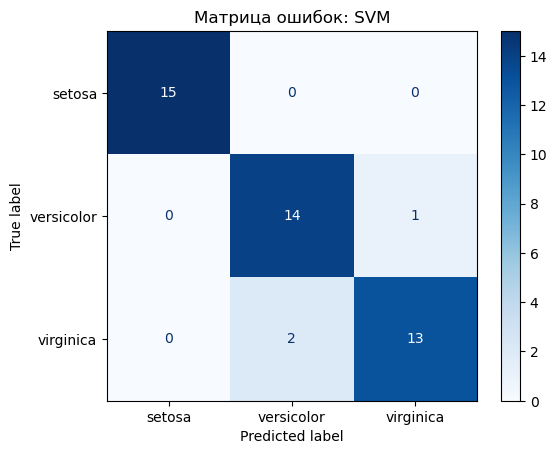

In [35]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: SVM')
plt.show()

### Матрица ошибок для логистической регрессии

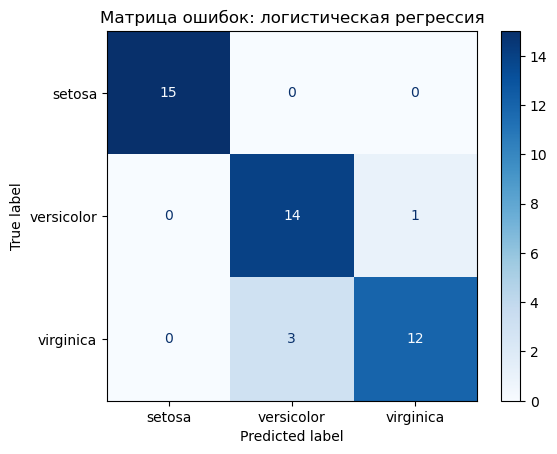

In [36]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: логистическая регрессия')
plt.show()

### Матрица ошибок для дерева решений

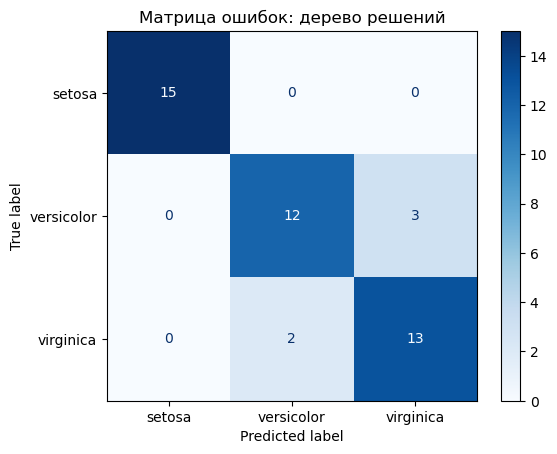

In [37]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок: дерево решений')
plt.show()

## 6. График, показывающий важность признаков в дереве решений

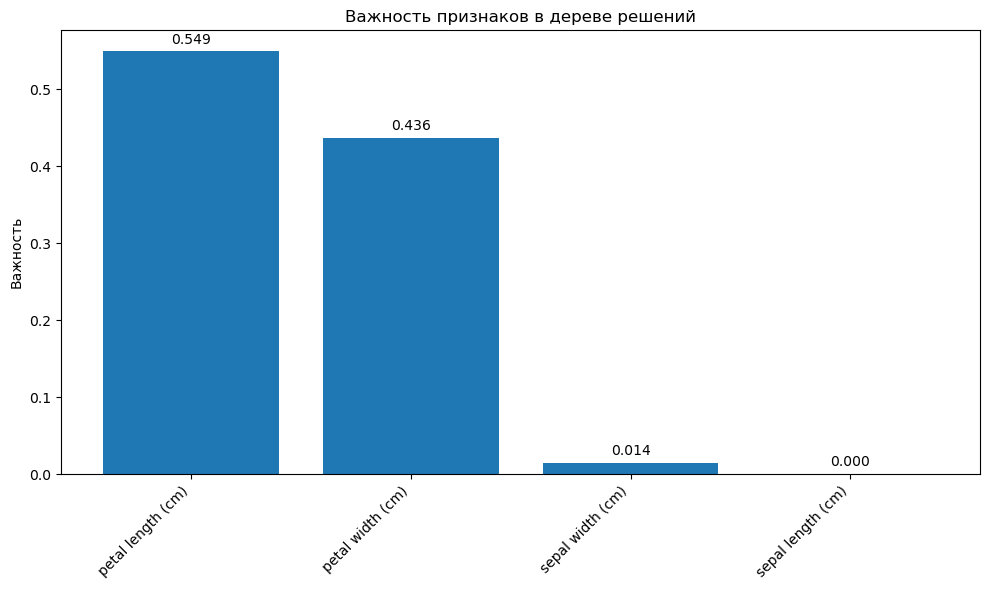

Важность признаков:
petal length (cm): 0.5490
petal width (cm): 0.4365
sepal width (cm): 0.0145
sepal length (cm): 0.0000


In [38]:
importances = tree_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title('Важность признаков в дереве решений')
plt.ylabel('Важность')

for i, value in enumerate(importances[indices]):
    plt.text(i, value + 0.01, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

print("Важность признаков:")
for idx in indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")

## 7. Визуализация дерева решений

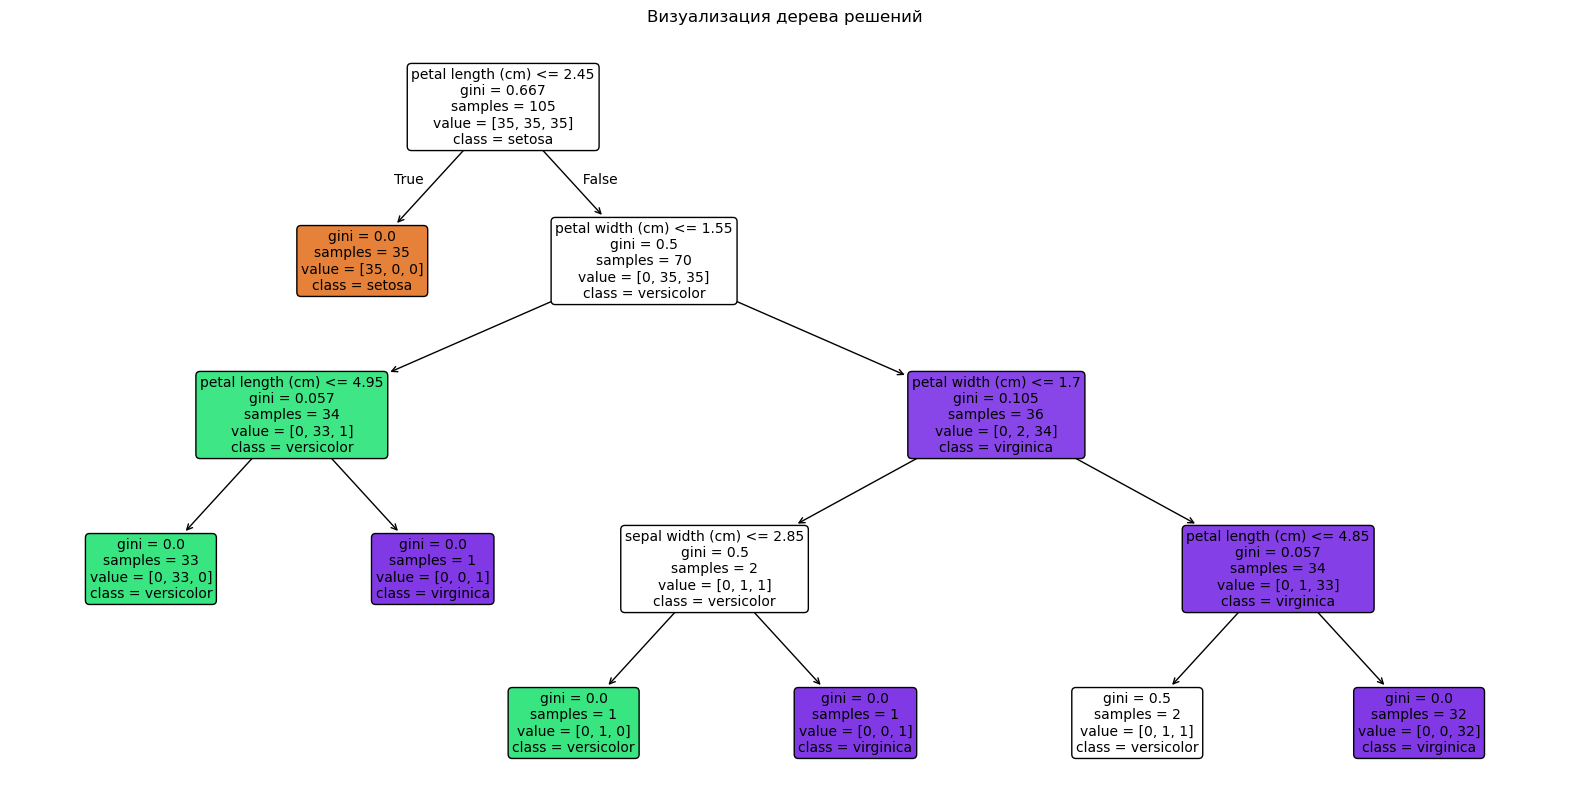

In [39]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Визуализация дерева решений')
plt.show()

## 7. Вывод правил дерева решений в текстовом виде

In [40]:
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print("Правила дерева решений:")
print(tree_rules)

Правила дерева решений:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: 1
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



## Вывод

#### Лучшей моедлью по Accurancy оказалась модель SVM. При этом все три модели показали очень даже высокое качество классификации на выбранном датасете. А модель де

In [41]:
best_model = results.sort_values(by='Accuracy', ascending=False).iloc[0]

print("\nИТОГОВЫЙ ВЫВОД")
print(f"Лучшая модель по Accuracy: {best_model['Модель']}")
print("Все три модели показали высокое качество классификации на датасете Iris.")
print("Дерево решений дополнительно позволило определить важность признаков и визуализировать процесс принятия решений.")


ИТОГОВЫЙ ВЫВОД
Лучшая модель по Accuracy: SVM
Все три модели показали высокое качество классификации на датасете Iris.
Дерево решений дополнительно позволило определить важность признаков и визуализировать процесс принятия решений.
